# M6.2 — Serial smoke sequence without persistent caches

Plan: [`plans/milestone_06/06_sequence_generation_plan.md`](../../plans/milestone_06/06_sequence_generation_plan.md).  
Next: `06_3_sequence_validation.ipynb`.

Preserves the historical Phase 2 execution contract: one 128 × 128 sequence, serial, with `use_persistent_cache=False` so clean source and particle correction are recomputed. That keeps original M6.2 timing/behavior reproducible after M6.4 cache support.

Before generating, removes any existing `bear_m6_smoke_001` under `data/generated/m6_2/`. Other scenario folders (`m6_4/`, `m6_5/`, …) are left untouched. The regenerated sequence is the canonical input for `06_3_sequence_validation.ipynb`.


In [1]:
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

!pip install --quiet --no-cache-dir "{ROOT}[fem,dev]" -c "{ROOT}/requirements.txt"

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ROOT=.


In [2]:
import pandas as pd
from IPython.display import display

from gummybear.datasets.generation_plan import (
    build_execution_plan,
    run_generation_plan,
    summarize_execution_plan,
    validate_generation_plan,
)
from gummybear.datasets.generation_workbook import load_generation_workbook
from gummybear_validation.milestone_06 import (
    clear_demo_sequence_outputs,
    load_sequence_manifest,
    preview_sequence_roles,
)

WORKBOOK_PATH = ROOT / "configs" / "m6" / "m6_generation_plan.xlsx"
OUTPUT_ROOT = ROOT / "data" / "generated" / "m6_2"


In [3]:
workbook = load_generation_workbook(WORKBOOK_PATH)
plan = validate_generation_plan(workbook, repo_root=ROOT)
execution_plan = build_execution_plan(plan, limit=1)
summary = summarize_execution_plan(
    execution_plan,
    disabled_sequence_count=len(plan.disabled_sequence_ids),
)
print(f"Workbook: {display_path(workbook.path)}")
print(f"SHA256: {workbook.sha256}")
summary.to_dict()


Workbook: configs/m6/m6_generation_plan.xlsx
SHA256: 4e6ac865c398b1c7c60e91a80f90270c993e3356568f5e71f79532ba7a378fde


{'workbook_path': 'configs/m6/m6_generation_plan.xlsx',
 'workbook_sha256': '4e6ac865c398b1c7c60e91a80f90270c993e3356568f5e71f79532ba7a378fde',
 'enabled_sequence_count': 1,
 'disabled_sequence_count': 0,
 'clean_group_count': 1,
 'particle_group_count': 1,
 'diffusion_group_count': 1,
 'sequence_count': 1,
 'frame_count': 6,
 'expected_clean_cache_hits': 0,
 'expected_clean_cache_misses': 1,
 'expected_particle_cache_hits': 0,
 'expected_particle_cache_misses': 1,
 'output_roots': ('data/generated/m6_2',),
 'resolutions': ((128, 128),),
 'plans_diffusion_operator_cache': False,
 'output_status_counts': {},
 'warnings': ()}

In [4]:
# Set True to reproduce the optional FEM-backed M6.2 smoke generation.
RUN_SMOKE = True

result = None
if RUN_SMOKE:
    clear_demo_sequence_outputs(execution_plan.jobs, OUTPUT_ROOT, repo_root=ROOT)
    result = run_generation_plan(
        execution_plan,
        output_root=OUTPUT_ROOT,
        limit=1,
        dry_run=False,
        max_workers=1,
        use_persistent_cache=False,
        verbose=True,
    )
    generated = result.generated[0]
    assert generated.clean_cache.status == "disabled"
    assert generated.particle_cache.status == "disabled"
    result


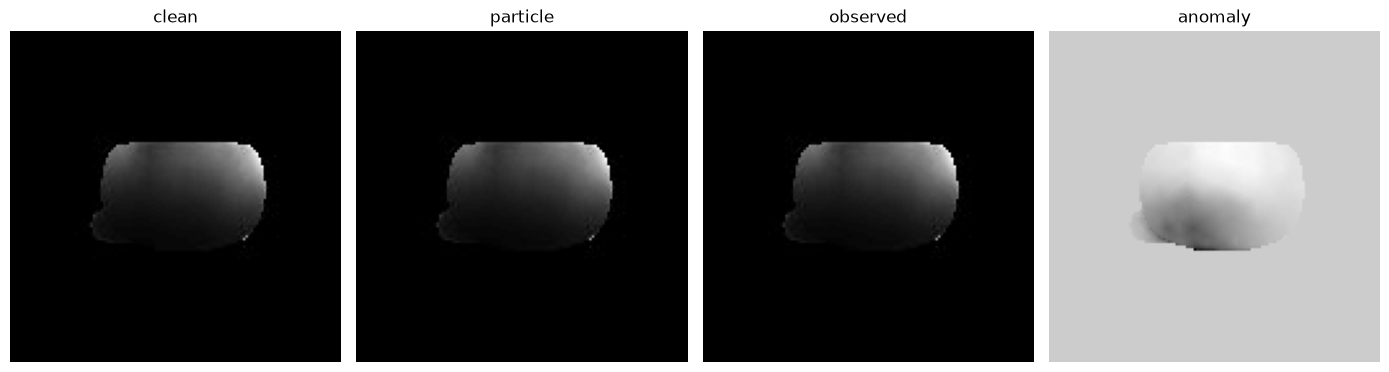

In [5]:
if result and result.generated:
    sequence_dir = Path(result.generated[0].output_path)
    manifest = load_sequence_manifest(sequence_dir)
    preview_sequence_roles(sequence_dir, roles=("clean", "particle", "observed", "anomaly"))
    {
        "sequence_id": manifest["sequence_id"],
        "representation": manifest["representation"],
        "caches": manifest["caches"],
        "generation": manifest["generation"],
        "frame_count": len(manifest["frames"]),
    }


## Historical M6.2 cache policy check

When the optional smoke run is enabled, this check documents that persistent source caches were bypassed and the manifest records that fact. The M6.4 cache demonstration lives in `06_4_generate_sequences.ipynb`.


In [6]:
if result and result.generated:
    generated = result.generated[0]
    assert generated.clean_cache.status == "disabled"
    assert generated.particle_cache.status == "disabled"
    assert manifest["caches"]["persistent_cache_used"] is False
    print("Historical M6.2 run confirmed: persistent source caches disabled.")


Historical M6.2 run confirmed: persistent source caches disabled.
